Tag 6:  KI-Testdrive

Projekt: 

Projektaufgaben:

es soll eine KI-Testdrive für die Kreditwürdigkeit erstellt werden.

In der CSV-Datei: kredit_testdrive.csv stehen die Daten.

Nehmen Sie Rückzahlung_ok als Zielvariable


Teil 1:

Dein bisheriges Skript macht gerade alles auf einmal:

- Daten laden
- Modell trainieren
- evaluieren
- Plots zeichnen

Hier könnte man erstellen:

train_model.py → trainiert und speichert Modell


Teil 2:

Hier ist die Flask-Oberfläche, d.h. amn erstellt die app.py

- app.py → lädt gespeichertes Modell und macht Vorhersagen
- templates/index.html → Eingabemaske


Teil 3:

- optional monitoring.py oder Logging-Datei → speichert Eingaben/Vorhersagen

Teil 1: train_model.py

Beste Parameter:
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Beste CV-F1: 0.6733553483553483

Test Accuracy: 0.7666666666666667
Test ROC-AUC: 0.8653198653198653

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79        33
           1       0.74      0.74      0.74        27

    accuracy                           0.77        60
   macro avg       0.76      0.76      0.76        60
weighted avg       0.77      0.77      0.77        60



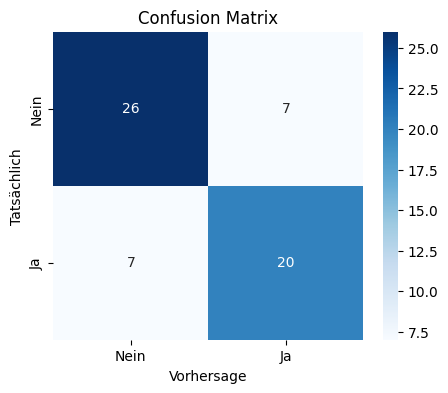

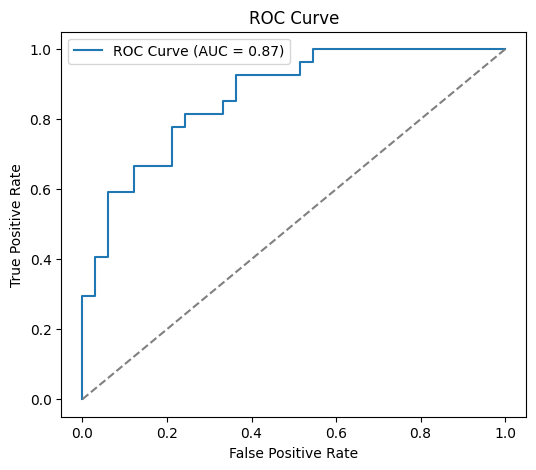


Verbessertes Modell wurde als kreditmodell_verbessert.pkl gespeichert.


In [7]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

# -----------------------------
# Daten laden
# -----------------------------
df = pd.read_csv("kredit_testdrive.csv")

# Features & Ziel
X = df[["Einkommen", "Alter", "Kreditbetrag"]]
y = df["Rückzahlung_ok"]

# -----------------------------
# Train-Test-Split
# stratify=y erhält Klassenverteilung
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# -----------------------------
# Pipeline
# Skalierung + Logistic Regression
# -----------------------------
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

# -----------------------------
# Hyperparameter-Suche
# -----------------------------
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"],
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Bestes Modell
best_model = grid_search.best_estimator_

print("Beste Parameter:")
print(grid_search.best_params_)
print("\nBeste CV-F1:", grid_search.best_score_)

# -----------------------------
# Testdaten vorhersagen
# -----------------------------
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Nein", "Ja"],
    yticklabels=["Nein", "Ja"]
)
plt.title("Confusion Matrix")
plt.xlabel("Vorhersage")
plt.ylabel("Tatsächlich")
plt.show()

# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# -----------------------------
# Modell speichern
# -----------------------------
joblib.dump(best_model, "kreditmodell.pkl")
print("\nVerbessertes Modell wurde als kreditmodell_verbessert.pkl gespeichert.")

Man sieht sehr gute Ergebnisse.

### Teil 2: Flask-App





Man könnte so eine Projektstruktur aufbauen:

projekt/
│
├── app.py
├── train_model.py
├── kreditmodell.pkl
├── kredit_testdrive.csv
├── prediction_logs.csv
│
└── templates/
    └── index.html

In [13]:
from flask import Flask, render_template, request
import joblib
import pandas as pd
import os
from datetime import datetime

app = Flask(__name__)

# Modell laden
model = joblib.load("kreditmodell.pkl")

LOG_FILE = "prediction_logs.csv"

@app.route("/", methods=["GET", "POST"])
def home():
    prediction_text = ""
    probability_text = ""

    if request.method == "POST":
        try:
            einkommen = float(request.form["einkommen"])
            alter = float(request.form["alter"])
            kreditbetrag = float(request.form["kreditbetrag"])

            # DataFrame für sklearn
            input_data = pd.DataFrame([{
                "Einkommen": einkommen,
                "Alter": alter,
                "Kreditbetrag": kreditbetrag
            }])

            prediction = model.predict(input_data)[0]
            probability = model.predict_proba(input_data)[0][1]

            if prediction == 1:
                prediction_text = "Vorhersage: Rückzahlung wahrscheinlich JA"
            else:
                prediction_text = "Vorhersage: Rückzahlung wahrscheinlich NEIN"

            probability_text = f"Wahrscheinlichkeit für JA: {probability:.2%}"

            # Logging für Monitoring
            log_row = pd.DataFrame([{
                "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "Einkommen": einkommen,
                "Alter": alter,
                "Kreditbetrag": kreditbetrag,
                "prediction": int(prediction),
                "probability_ja": float(probability)
            }])

            if os.path.exists(LOG_FILE):
                log_row.to_csv(LOG_FILE, mode="a", header=False, index=False)
            else:
                log_row.to_csv(LOG_FILE, mode="w", header=True, index=False)

        except ValueError:
            prediction_text = "Bitte gültige numerische Werte eingeben."

    return render_template(
        "index.html",
        prediction_text=prediction_text,
        probability_text=probability_text
    )

# Für Jupyter Notebook:
app.run(debug=False, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [11/Mar/2026 15:02:19] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [11/Mar/2026 15:02:47] "POST / HTTP/1.1" 200 -
127.0.0.1 - - [11/Mar/2026 15:03:12] "POST / HTTP/1.1" 200 -
127.0.0.1 - - [11/Mar/2026 15:03:32] "POST / HTTP/1.1" 200 -
127.0.0.1 - - [11/Mar/2026 15:03:52] "POST / HTTP/1.1" 200 -


Teil 3:


Drift Modell

Hier vergleicht man:


Data Drift untersuchen: einfacher Vergleich

Du kannst Trainingsdaten und Produktionsdaten vergleichen.



--- Einkommen ---
Training Mittelwert: 3472.48
Produktion Mittelwert: 3214.285714285714
Training Std: 1452.1934923750632
Produktion Std: 1185.226520443204


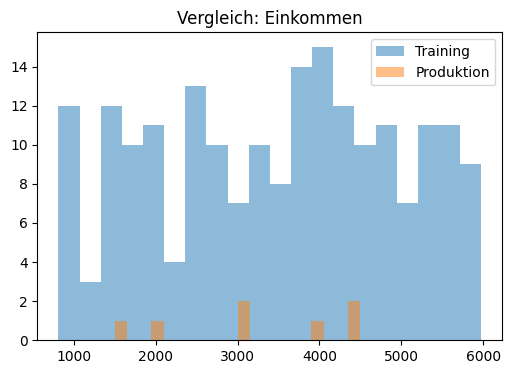


--- Alter ---
Training Mittelwert: 41.57
Produktion Mittelwert: 39.285714285714285
Training Std: 13.71552690901665
Produktion Std: 14.851647335276601


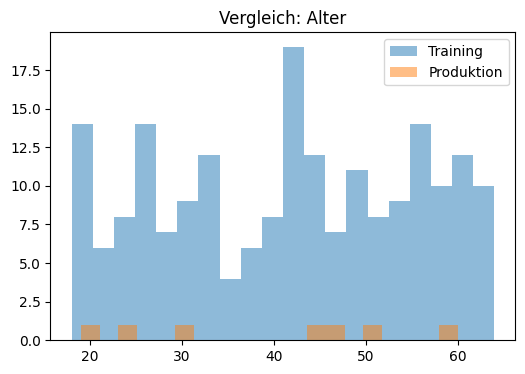


--- Kreditbetrag ---
Training Mittelwert: 2808.055
Produktion Mittelwert: 3214.285714285714
Training Std: 1265.429806409565
Produktion Std: 1728.6107827082528


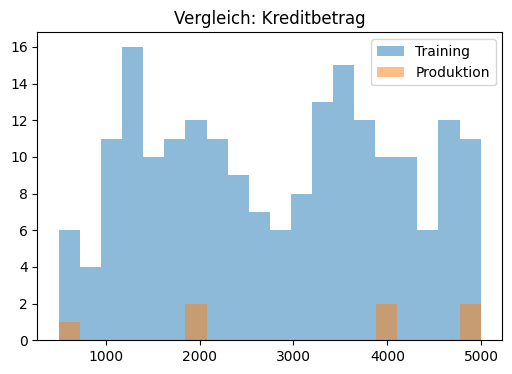

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Trainingsdaten
train_df = pd.read_csv("kredit_testdrive.csv")

# Produktionsdaten / Logs
prod_df = pd.read_csv("prediction_logs.csv")

train_features = train_df[["Einkommen", "Alter", "Kreditbetrag"]]
prod_features = prod_df[["Einkommen", "Alter", "Kreditbetrag"]]

for col in train_features.columns:
    print(f"\n--- {col} ---")
    print("Training Mittelwert:", train_features[col].mean())
    print("Produktion Mittelwert:", prod_features[col].mean())
    print("Training Std:", train_features[col].std())
    print("Produktion Std:", prod_features[col].std())

    plt.figure(figsize=(6, 4))
    plt.hist(train_features[col], bins=20, alpha=0.5, label="Training")
    plt.hist(prod_features[col], bins=20, alpha=0.5, label="Produktion")
    plt.title(f"Vergleich: {col}")
    plt.legend()
    plt.show()

Verbesserung mit PSI

Drift mit Statistik messen

Ein bloßer Blick auf Histogramme ist gut, aber noch besser ist ein Maß.

Ein sehr bekanntes Maß ist der PSI (Population Stability Index).

Damit kann man zwei Verteilungen vergleichen:

Referenzdaten = Trainingsdaten

aktuelle Daten = Produktionsdaten

In [11]:
import numpy as np
import pandas as pd

def calculate_psi(expected, actual, bins=10):
    expected = np.array(expected)
    actual = np.array(actual)

    breakpoints = np.percentile(expected, np.arange(0, bins + 1) / bins * 100)
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    expected_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_counts = np.where(expected_counts == 0, 0.0001, expected_counts)
    actual_counts = np.where(actual_counts == 0, 0.0001, actual_counts)

    psi = np.sum((actual_counts - expected_counts) * np.log(actual_counts / expected_counts))
    return psi

In [15]:
train_df = pd.read_csv("kredit_testdrive.csv")
prod_df = pd.read_csv("prediction_logs.csv")

for col in ["Einkommen", "Alter", "Kreditbetrag"]:
    psi_value = calculate_psi(train_df[col], prod_df[col])
    print(f"{col}: PSI = {psi_value:.4f}")

Einkommen: PSI = 3.8862
Alter: PSI = 2.8375
Kreditbetrag: PSI = 4.7407


Hier hat man zu wenig Daten man muss hier mehr sammeln!

Faustregel für PSI

Oft verwendet man:

PSI < 0.1 → kaum Drift

$0.1 \leq PSI < 0.25$ → moderate Drift

PSI $\geq 0.25$ → starke Drift

Das sind praktische Richtwerte, keine Naturgesetze.